In [36]:
import pandas as pd
import ir_datasets
from src.data import DATA_DIR_INTERIM
from topic_gen.evaluate import QrelsEvaluator, CohenKappa, MeanAverageError, AreaUnderReceiver, binarize_qrels
from src.data import load_qrels_from_path, get_dataset
from src.utils import format_score
from topic_gen import logger
from ir_datasets_longeval import load
logger.setLevel("DEBUG")

### Binary Relevance Labels

In [ ]:
# all overwrites qrels with defould qrels from dataset

In [52]:
# Train test leakage
# test on 648 qrels
dataset = get_dataset("longeval")
# t = dataset.topic_components(nqueries=1, ndocsneg=3, ndocspos=3)
q = dataset.qrel_components()

In [ ]:
# test on 648 qrels
dataset = get_dataset("longeval-45-C")
# t = dataset.topic_components(nqueries=1, ndocsneg=3, ndocspos=3)
q = dataset.qrel_components()

[topic_gen] [WARNING] (data.py:332) No query variants available for this dataset. Returning only the original query.


In [ ]:
# test on 2250 qrels
dataset = get_dataset("longeval-C-45")
# t = dataset.topic_components(nqueries=1, ndocsneg=3, ndocspos=3)
q = dataset.qrel_components()

[topic_gen] [WARNING] (data.py:332) No query variants available for this dataset. Returning only the original query.


In [ ]:
for dataset_name in ["longeval-45-45"]:#["longeval", "longeval-45-45", "longeval-45-C", "longeval-C-45"]:
    print(dataset_name)
    # test on 2250 qrels
    dataset = get_dataset(dataset_name)
    # t = dataset.topic_components(nqueries=1, ndocsneg=3, ndocspos=3)
    q = dataset.qrel_components()

    # Load generated qrels from path
    BASE_DIR = DATA_DIR_INTERIM / "qrels-longeval-topics-generated"
    predictions, names, metadata = load_qrels_from_path(BASE_DIR)

    # binarize qrels
    predictions = [binarize_qrels(qrels) for qrels in predictions]

    references = q["qrels"]
    references["relevance"] = references["relevance"].apply(
        lambda x: 1 if x > 0 else 0)
    
    
    # Evaluate qrels
    res = QrelsEvaluator.experiment(
        predictions=predictions,
        references=references,
        measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
        bootstrap=20,
        names=names)
    
    df = pd.DataFrame(res)
    df["score"] = df.apply(format_score, axis=1)
    missing = (
        df[["name", "missing"]].drop_duplicates().set_index("name").to_dict()["missing"]
    )
    df = df.pivot(index="name", columns="measure", values="score").reset_index()
    df["missing"] = df["name"].map(missing)
    df = df.merge(metadata, left_on="name", right_on="date")
    
    df = df[df["data"] == dataset_name]
    print(df[["topics_model", "CohenKappa", "MeanAverageError", "AreaUnderReceiver", "missing"]])

longeval


[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 4/99 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 2/648 qrels in references but not in predictions.


         topics_model CohenKappa MeanAverageError AreaUnderReceiver  missing
2               human  0.02±0.04        0.67±0.03         0.52±0.03        0
3  qwen3-30B-no-think  0.19±0.05        0.45±0.03         0.61±0.03        2
longeval-45-45


[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 2/1550 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 4/1578 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 61/1578 qrels in references but not in predictions.


         topics_model  CohenKappa MeanAverageError AreaUnderReceiver  missing
0               human  -0.07±0.04        0.53±0.02         0.46±0.02        2
1  qwen3-30B-no-think  -0.01±0.04        0.51±0.02         0.49±0.03        0
longeval-45-C


[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 4/99 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 2/648 qrels in references but not in predictions.


         topics_model CohenKappa MeanAverageError AreaUnderReceiver  missing
4               human  0.02±0.03        0.66±0.04         0.53±0.03        0
5  qwen3-30B-no-think  0.08±0.05        0.43±0.03         0.54±0.03        0
longeval-C-45


[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 2/1578 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 7/2368 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 88/2368 qrels in references but not in predictions.


         topics_model  CohenKappa MeanAverageError AreaUnderReceiver  missing
6               human  -0.08±0.03        0.54±0.02         0.45±0.01        7
7  qwen3-30B-no-think   0.01±0.03        0.50±0.02         0.51±0.02       88


In [19]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-longeval-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

[topic_gen] [WARNING] (data.py:66) Metadata not found for result 2025-12-02_14:08:06, skipping...


In [20]:
references = q["qrels"]
references["relevance"] = references["relevance"].apply(
    lambda x: 1 if x > 0 else 0)

In [21]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=references,
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 2/1550 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:374) Missing qrels: 4/1578 qrels in references but not in predictions.


In [29]:
df = pd.DataFrame(res)
df["score"] = df.apply(format_score, axis=1)
missing = (
    df[["name", "missing"]].drop_duplicates().set_index("name").to_dict()["missing"]
)
df = df.pivot(index="name", columns="measure", values="score").reset_index()
df["missing"] = df["name"].map(missing)
df = df.merge(metadata, left_on="name", right_on="date")

## **Alignment:** How well align generated qrels based on generated topics with the original qrels?

In [35]:
model = "qwen3-30B-no-think"  # df["model"]
prompt_sorter = [
    "human",
    "topic-query",
    "topic-docs-pos",
    "topic-docs-neg",
    "topic-query-docs-pos",
    "topic-query-docs-neg",
    "topic-contrastive",
    "topic-query-contrastive"
]
df["topics_prompt"] = pd.Categorical(df["topics_prompt"], prompt_sorter)
df = df[df["data"] == "longeval-45-45"]

df[(df["prompt"] == "-DNA-zero-shot") & \
    #   (df["model"] == model) &
   ((df["model"] == df["topics_model"]) | (df["topics_model"] == "human"))] \
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True]) #\
        # [["name", "model", "topics_prompt", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver", "missing"]]

,name,AreaUnderReceiver,CohenKappa,MeanAverageError,missing,date,model,data,prompt,k,...,topics_date,topics_model,topics_data,topics_prompt,topics_k,topics_nqueries,topics_ndocspos,topics_ndocsneg,topics_output,topics_task
1,2025-12-02_13:52:41,0.49±0.02,-0.01±0.03,0.51±0.02,0,2025-12-02_13:52:41,qwen3-30B-no-think,longeval-45-45,-DNA-zero-shot,None,...,2025-12-02_13:38:15,qwen3-30B-no-think,longeval-45-45,topic-query-contrastive,None,1.0,1.0,1.0,../data/interim/topics-longeval,topics


## Plot 

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 7/2944 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 14/2937 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 16/2935 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 16/2935 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 18/2933 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 5/2946 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 7/2944 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 18/2933 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 22/2929 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) 

In [46]:
df = pd.DataFrame(res)
df = df.merge(metadata, left_on="name", right_on="date")

In [ ]:
def plot(subset_prompt_list, df, x="topics_nqueries"):
    df = df.copy()
    baseline = df[df["topics_prompt"] == "human"]
    df = df[df["topics_prompt"].isin(subset_prompt_list)]
    unique_prompts = df["topics_prompt"].unique()
    palette = sns.color_palette("tab10", len(unique_prompts))
    color_map = dict(zip(unique_prompts, palette))

    for measure_name, g in df.groupby("measure"):
        fig, ax = plt.subplots(figsize=(6, 4))
        g = g.copy()
        g['ci_lower'] = g['value'] - g['ci']
        g['ci_upper'] = g['value'] + g['ci']

        sns.lineplot(
            data=g,
            x=x,
            y="value",
            hue="topics_prompt",
            palette=color_map,
            ax=ax,
            errorbar=None
        )
        for prompt_name, sub_g in g.groupby("topics_prompt"):
            sub_g = sub_g.sort_values(x)
            color = color_map[prompt_name]

            ax.fill_between(
                sub_g[x],
                sub_g['ci_lower'],
                sub_g['ci_upper'],
                color=color,
                alpha=0.15
            )

        ax.axhline(y=float(baseline[baseline["measure"] == measure_name]["value"].iloc[0]), linestyle='--',
                   label=f"Original Topic", color='gray')
        ax.set_title(f"Measure: {measure_name}")

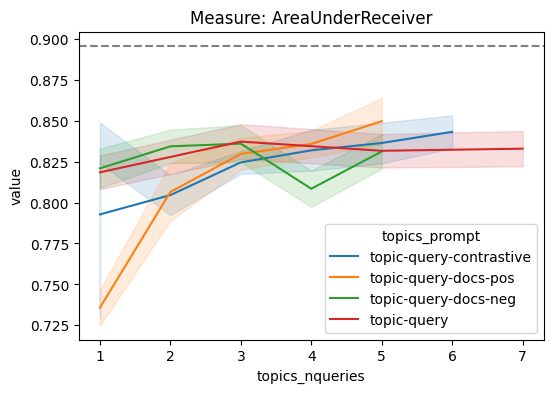

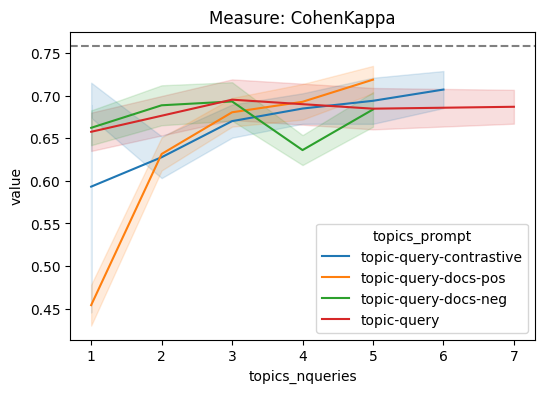

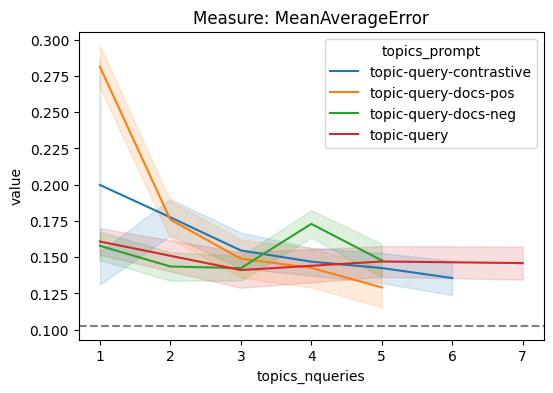

In [10]:
plot(['topic-query-docs-pos', 'topic-query-docs-neg',
     'topic-query', 'topic-query-contrastive'], df)

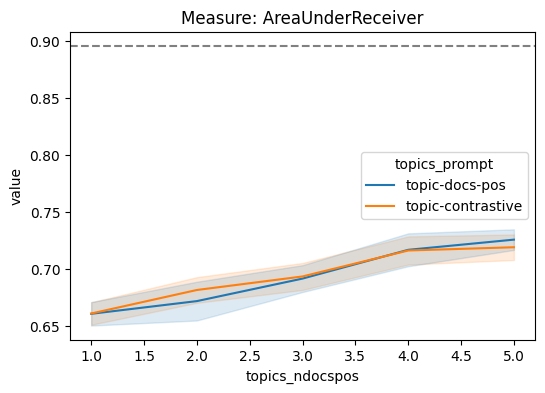

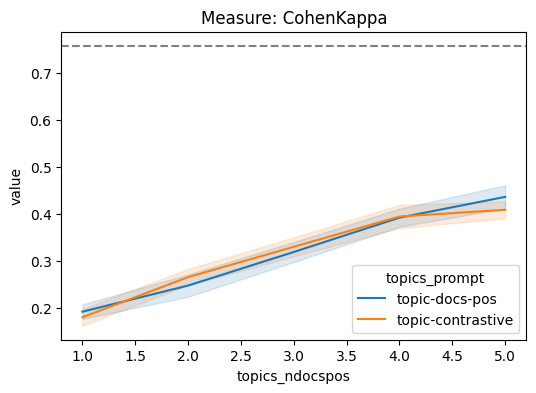

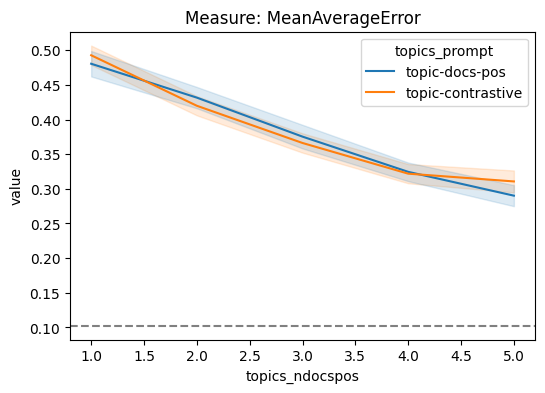

In [50]:
plot(['topic-docs-pos', 'topic-contrastive'], df, x="topics_ndocspos")

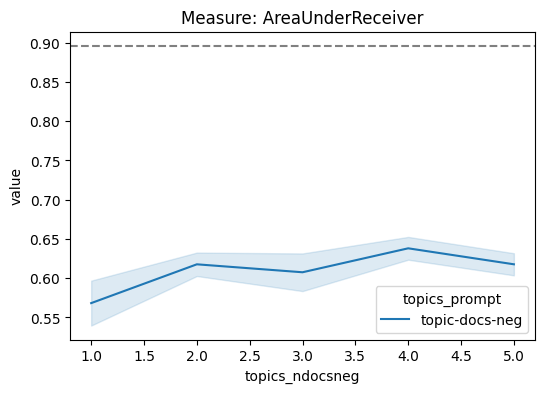

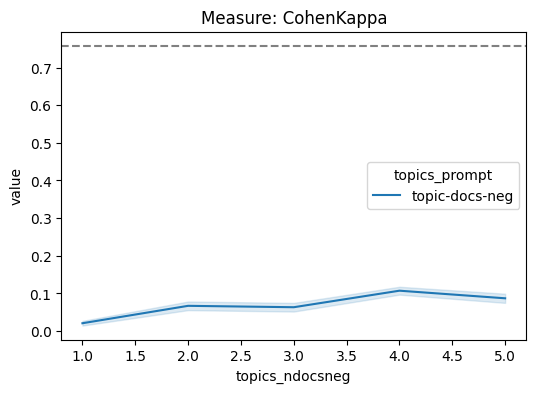

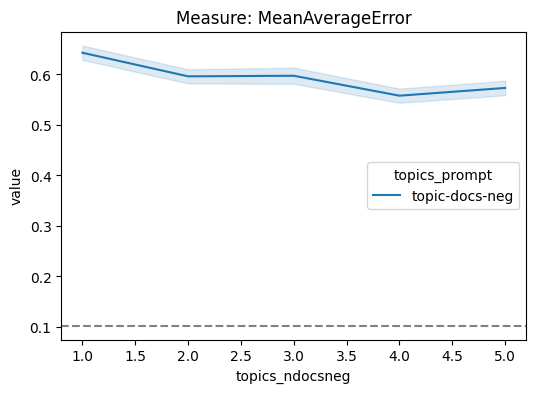

In [51]:
plot(['topic-docs-neg'], df, x="topics_ndocsneg")

### Per-Topic

In [23]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

In [24]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    # bootstrap=20,
    per_query=True,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 7/2944 qrels in references but not in predictions.
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class 

In [26]:
df = pd.DataFrame(res)

In [ ]:
best = df[df["name"] == "2025-11-27_09:21:47"]

In [33]:
best[best["measure"] == "CohenKappa"]

,topic_id,measure,value,name
19344,301,CohenKappa,0.365079,2025-11-27_09:21:47
19347,302,CohenKappa,0.695652,2025-11-27_09:21:47
19350,303,CohenKappa,NaN,2025-11-27_09:21:47
19353,304,CohenKappa,0.000000,2025-11-27_09:21:47
19356,305,CohenKappa,0.466667,2025-11-27_09:21:47
...,...,...,...,...
20073,696,CohenKappa,1.000000,2025-11-27_09:21:47
20076,697,CohenKappa,NaN,2025-11-27_09:21:47
20079,698,CohenKappa,0.813559,2025-11-27_09:21:47
20082,699,CohenKappa,1.000000,2025-11-27_09:21:47


<Axes: title={'center': 'Cohen Kappa Distribution for the best topic prompt over all topics'}, ylabel='Frequency'>

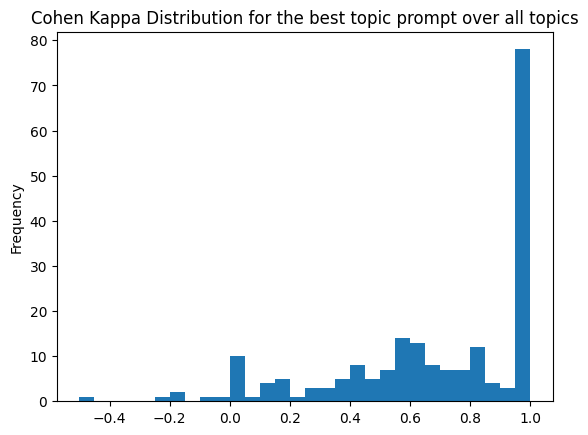

In [38]:
best[best["measure"] == "CohenKappa"]["value"].plot.hist(
    bins=30, title="Cohen Kappa Distribution for the best topic prompt over all topics")